In [1]:
import pandas as pd

master = pd.read_csv("../data/cleaned/master_dataset.csv")

master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

In [2]:
snapshot_date = (
    master["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

In [3]:
rfm = master.groupby("customer_unique_id").agg(
{
"order_purchase_timestamp":
lambda x: (snapshot_date - x.max()).days,

"order_id":
"nunique",

"revenue":
"sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

In [4]:
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [5]:
rfm["R_score"] = pd.qcut(
rfm["Recency"],
5,
labels=[5,4,3,2,1]
)

rfm["F_score"] = pd.qcut(
rfm["Frequency"].rank(method="first"),
5,
labels=[1,2,3,4,5]
)

rfm["M_score"] = pd.qcut(
rfm["Monetary"],
5,
labels=[1,2,3,4,5]
)

In [6]:
rfm["RFM_Score"] = (
rfm["R_score"].astype(str)
+
rfm["F_score"].astype(str)
+
rfm["M_score"].astype(str)
)

In [7]:
rfm["Segment"] = "Others"

rfm.loc[
(rfm["R_score"] >= 4)
&
(rfm["F_score"] >= 4),
"Segment"
] = "Champions"

In [8]:
rfm["Segment"].value_counts()

Segment
Others       65452
Champions    30644
Name: count, dtype: int64

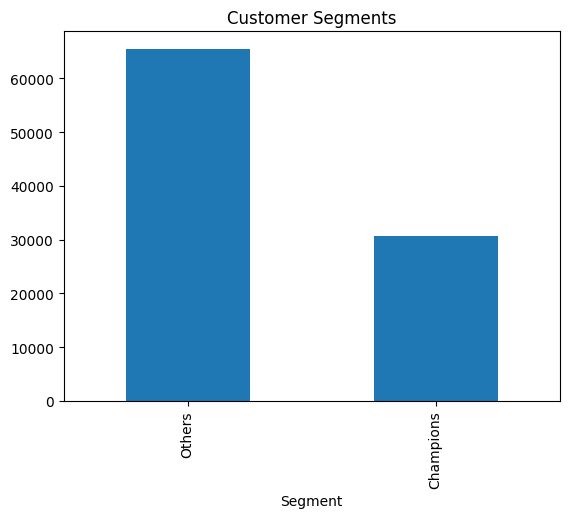

In [9]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
kind="bar"
)

plt.title("Customer Segments")
plt.show()